## 💻 **Guía del Laboratorio Práctico — Clase 8: Fundamentos de Data Science**

---

## Bloque 1: Fundamentos de Aprendizaje Supervisado y Carga de Datos (15 min)

### 📝 Teoría

#### ¿Qué es el Aprendizaje Supervisado?
El **Aprendizaje Supervisado** (*Supervised Learning*) es la rama del Machine Learning donde el modelo aprende a partir de ejemplos **etiquetados**: cada fila del dataset tiene tanto las variables de entrada ($X$) como la respuesta correcta ($y$, llamada *label* o *target*).

La idea central es que el algoritmo descubra una función $f$ tal que:
$$\hat{y} = f(X) \approx y_{real}$$

Una vez entrenado, ese $f$ puede predecir $y$ para filas **nuevas** que nunca vio antes.

#### Dos grandes familias de problemas
| Tipo | Variable objetivo $y$ | Ejemplo en este laboratorio |
|------|----------------------|-----------------------------|
| **Regresión** | Continua (número real) | IPCF (ingreso per cápita familiar) |
| **Clasificación** | Categórica (clase discreta) | ¿El hogar está bajo la línea de pobreza? |

#### Los datos: EPH (Encuesta Permanente de Hogares)
La EPH es la fuente oficial de INDEC para medir mercado laboral y condiciones de vida en Argentina. Tiene dos archivos relacionados:
- **`usu_hogar`**: una fila por hogar (vivienda, servicios, cantidad de miembros).
- **`usu_individual`**: una fila por persona (edad, educación, ingresos, relación con el hogar).

Para construir un modelo, necesitamos **joinear** ambas tablas usando las claves `CODUSU` y `NRO_HOGAR`.

#### Variables que vamos a usar
| Variable | Descripción | Tipo |
|----------|-------------|------|
| `IV1` | Tipo de vivienda (1=Casa, 2=Dpto, ...) | Feature ordinal |
| `IV2` | Número de ambientes | Feature numérica |
| `IX_TOT` | Total de personas en el hogar | Feature numérica |
| `NIVEL_ED` | Nivel educativo del Jefe de Hogar | Feature ordinal |
| `IPCF` | **Ingreso Per Cápita Familiar** | **Target (lo que predecimos)** |

> **Nota de clase:** el IPCF a veces llega con coma decimal en lugar de punto (formato europeo). Por eso el código incluye una sanitización explícita.


In [17]:
# ==============================================================================
# PUNTO 6 Y 7: Configuración de Entorno y Sanitización del Target Continuo
# ==============================================================================

# --- Librerías esenciales ---
import pandas as pd          # Manipulación de DataFrames (tablas relacionales en Python)
import numpy as np           # Álgebra lineal y operaciones numéricas vectorizadas
import matplotlib.pyplot as plt  # Visualización estática de bajo nivel
import seaborn as sns        # Visualización de alto nivel (construida sobre matplotlib)

# --- Carga de los archivos de la EPH ---
# sep=';' porque el separador del archivo es punto y coma (no coma)
df_hogar      = pd.read_csv("usu_hogar_T425.txt", sep=";")
df_individual = pd.read_csv("usu_individual_T425.txt", sep=";")

# --- Extraemos solo al Jefe de Hogar (CH03 == 1) ---
# El nivel educativo del jefe es un proxy importante del capital humano del hogar
df_jefes = df_individual[df_individual['CH03'] == 1][['CODUSU', 'NRO_HOGAR', 'NIVEL_ED']]

# --- Join entre hogares y jefes ---
# inner join: solo conservamos hogares que tienen jefe identificado en ambas tablas
df = pd.merge(df_hogar, df_jefes, on=['CODUSU', 'NRO_HOGAR'], how='inner')

# --- Definición de features y target ---
features = ['IV1', 'IV2', 'IX_TOT', 'NIVEL_ED']  # variables explicativas (X)
target   = 'IPCF'                                  # variable a predecir (y)

# --- Sanitización del target ---
# Problema real: la EPH a veces exporta IPCF con coma decimal ('633333,33')
# Python no puede convertir '633333,33' a float directamente → error
if df[target].dtype == 'object':                      # si llegó como texto
    df[target] = df[target].astype(str).str.replace(',', '.')  # ',' → '.'

# errors='coerce': si alguna celda no es convertible, la vuelve NaN (en vez de romper)
df[target] = pd.to_numeric(df[target], errors='coerce')

# --- Dataset limpio: eliminamos filas sin target válido ---
df_model = df[features + [target]].dropna(subset=[target]).copy()

print(f"Dataset listo y corregido. Registros válidos: {df_model.shape[0]}")
print(f"Tipo de datos de la variable objetivo ({target}): {df_model[target].dtype}")
df_model.head()


Dataset listo y corregido. Registros válidos: 15534
Tipo de datos de la variable objetivo (IPCF): float64


/tmp/ipykernel_7624/4205817410.py:11: DtypeWarning: Columns (102,105) have mixed types. Specify dtype option on import or set low_memory=False.
  df_individual = pd.read_csv("usu_individual_T425.txt", sep=";")


,IV1,IV2,IX_TOT,NIVEL_ED,IPCF
0,1,3,5,2,0.00
1,1,3,3,4,633333.33
2,1,4,3,6,0.00
3,1,3,5,2,240000.00
4,1,2,2,2,930000.00


# **Bloque 2: Limpieza, Imputación y Preprocesamiento Avanzado (20 min)**

### 📝 Teoría

#### ¿Por qué es necesario preprocesar?
Los algoritmos de Machine Learning son funciones matemáticas que esperan **matrices numéricas densas** sin valores faltantes. En la vida real los datos llegan sucios: celdas vacías, códigos especiales de ‘no respuesta’, escalas muy dispares, y variables categóricas representadas como texto.

El preprocesamiento tiene tres pasos clave:

---

#### 1️⃣ Imputación de valores faltantes (Punto 4)
**Nunca eliminar filas a ciegas.** Eliminar todas las filas con NaN puede reducir la muestra a la mitad y sesgar los resultados (p.ej. si los ricos responden menos cierta pregunta).

Alternativas:
- **Mediana**: robusta ante outliers (preferida para variables sesgadas como ingresos).
- **Media**: funciona bien en distribuciones simétricas.
- **Moda**: para variables categóricas.
- **KNN Imputer / IterativeImputer**: usa otros atributos para estimar el valor faltante (más sofisticado).

> ⚠️ **Regla de oro**: el imputador se **entrena solo con los datos de train** y luego se aplica a test. Si entrenamos con test estamos filtrando información del futuro (*data leakage*).

---

#### 2️⃣ Escalado y Normalización (Punto 11)
Muchos algoritmos (regresión lineal con regularización, SVM, KNN, redes neuronales) son **sensibles a la escala** de las variables. Si `IX_TOT` va de 1 a 15 y `IPCF` va de 0 a 2.000.000, la variable de ingresos dominará el gradiente.

**Estandarización (Z-score):**
$$X_{scaled} = \frac{X - \mu}{\sigma}$$
Transforma cada feature para que tenga **media 0 y desviación estándar 1**. Es la opción más común.

---

#### 3️⃣ Partición Train / Test (Punto 5)
Para estimar cuán bien generaliza el modelo a datos nuevos, reservamos una porción del dataset (**test set**) que el modelo **nunca ve durante el entrenamiento**. El split típico es 80% train / 20% test.

> El parámetro `random_state=42` fija la semilla aleatoria para que los resultados sean **reproducibles**.


In [18]:
# ==============================================================================
# PUNTO 4, 5 Y 11: Limpieza, Imputación, Escalado y Codificación
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# --- Limpieza de códigos de no-respuesta ---
# En la EPH, el valor 99 en IV2 significa 'sin dato' (no son 99 ambientes reales)
# Lo reemplazamos por NaN para que el imputador los trate correctamente
df_model['IV2'] = df_model['IV2'].replace({99: np.nan})

# --- Separación de X (features) e y (target) ---
X = df_model[features]   # matriz de entrada: (n_muestras, n_features)
y = df_model[target]     # vector objetivo: (n_muestras,)

# --- División train/test ---
# test_size=0.2 -> 20% para evaluar, 80% para entrenar
# random_state=42 -> semilla fija para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

# --- Imputación por mediana ---
# fit_transform en train: aprende la mediana de cada columna CON datos de train
# transform en test:      aplica esa misma mediana (sin recalcular) → evita leakage
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)  # aprende + transforma
X_test_imputed  = imputer.transform(X_test)        # solo transforma (con la mediana de train)

# --- Estandarización (Z-score): media=0, desvíación estándar=1 ---
# Misma lógica: fit solo en train para no contaminar con info del test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)  # aprende μ y σ + aplica
X_test_scaled  = scaler.transform(X_test_imputed)       # aplica μ y σ de train

print("Preprocesamiento completado. Datos imputados y estandarizados.")
print(f"Ejemplo media de la primera feature en train (debería ser ~0): {X_train_scaled[:,0].mean():.4f}")


Preprocesamiento completado. Datos imputados y estandarizados.


# **Bloque 3: Regresión Lineal y Diagnóstico Visual (20 min)**

### 📝 Teoría

#### Regresión Lineal (Punto 1)
La **Regresión Lineal** supone que la relación entre las features y el target puede aproximarse con un hiperplano:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Los coeficientes $\beta$ se estiman por **Mínimos Cuadrados Ordinarios (MCO)**, que minimiza la suma de los errores al cuadrado:
$$\min_{\beta} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

**Ventajas:**
- Muy rápido de entrenar (solución analítica cerrada).
- Interpretable: cada $\beta_k$ mide el efecto marginal de $x_k$ sobre $y$ manteniendo el resto fijo.

**Limitaciones:**
- Supone relación lineal entre X e y (puede ser muy restrictivo).
- Sensible a valores atípicos (*outliers*) porque los eleva al cuadrado.

---

#### Diagnóstico Visual de Residuos (Punto 10)
Un modelo nunca predice a la perfección. El **residuo** es la diferencia entre el valor real y el predicho:
$$e_i = y_i - \hat{y}_i$$

Si el modelo captura bien la estructura de los datos, los residuos deben:
1. **Distribuirse cerca del cero** (sin sesgo sistemático).
2. **No tener patrones** en función de $\hat{y}$ (homocedasticidad).
3. **Aproximarse a una distribución normal** (supuesto del MCO).

Si los residuos forman un embudo, una curva o tienen colas muy pesadas, es señal de que el modelo lineal **no alcanza** para capturar la complejidad de los datos.

> **Qué esperar en este dataset:** Los ingresos tienen una distribución muy sesgada a la derecha (muchos ceros, pocos muy altos). La Regresión Lineal simple probablemente muestre residuos asimétricos → motivación para usar modelos más complejos.


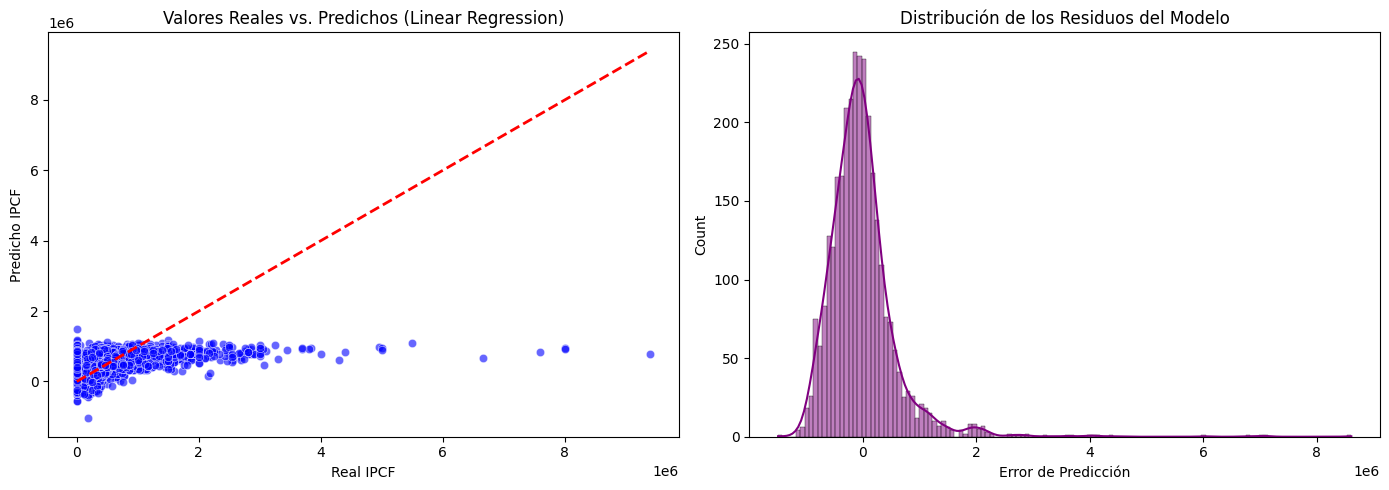

In [19]:
# ==============================================================================
# PUNTO 1 Y 10: Laboratorio Regresión Lineal y Diagnósticos Gráficos
# ==============================================================================
from sklearn.linear_model import LinearRegression

# --- Instanciar y entrenar el modelo ---
# LinearRegression usa MCO internamente (solución exacta, sin gradiente)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)   # aprende los coeficientes beta

# --- Coeficientes del modelo (interpretación) ---
print("Coeficientes del modelo (efecto marginal por feature):")
for fname, coef in zip(features, lr_model.coef_):
    print(f"  {fname}: {coef:+,.0f} pesos")
print(f"  Intercepto: {lr_model.intercept_:+,.0f} pesos")
print()

# --- Predicciones sobre el conjunto de test ---
y_pred_lr = lr_model.predict(X_test_scaled)

# --- Gráficos de diagnóstico ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Valores Reales vs Predichos
# La línea roja punteada es la 'predicción perfecta' (y_real == y_pred)
# Cuanto más cerca estén los puntos de esa línea, mejor el modelo
sns.scatterplot(x=y_test, y=y_pred_lr, ax=ax[0], alpha=0.6, color='blue')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_title("Valores Reales vs. Predichos (Linear Regression)")
ax[0].set_xlabel("IPCF Real")
ax[0].set_ylabel("IPCF Predicho")

# Gráfico 2: Distribución de Residuos
# Si la curva KDE es una campana centrada en 0 -> residuos normales (buena señal)
# Colas gruesas o asimetría -> el modelo no captura toda la varianza
residuals = y_test - y_pred_lr
sns.histplot(residuals, kde=True, ax=ax[1], color='purple')
ax[1].axvline(0, color='red', linestyle='--', label='Error = 0')
ax[1].set_title("Distribución de los Residuos del Modelo")
ax[1].set_xlabel("Error de Predicción (Real - Predicho)")
ax[1].legend()

plt.tight_layout()
plt.show()


# Bloque 4: Árboles de Decisión, Random Forest y Métricas (20 min)

### 📝 Teoría

#### Árboles de Decisión (Punto 2)
Un **Árbol de Decisión** divide el espacio de features con preguntas binarias sucesivas (tipo if-else). En cada nodo se elige la feature y el umbral que mejor separa los datos según un criterio:
- **Regresión**: minimiza la varianza dentro de cada rama (MSE).
- **Clasificación**: minimiza la impureza Gini o maximiza la ganancia de información.

**Ventaja clave:** muy interpretable, se puede visualizar como un diagrama de flujo.

**Problema central:** **sobreajuste** (*overfitting*). Un árbol sin poda memoriza los datos de train y falla en test. Por eso limitamos su profundidad con `max_depth`.

---

#### Random Forest y Ensemble Learning (Punto 2)
**Random Forest** resuelve el problema del sobreajuste mediante **Bagging** (*Bootstrap Aggregating*):
1. Se generan $B$ sub-muestras aleatorias **con reposición** del dataset de entrenamiento.
2. Se entrena un árbol independiente en cada sub-muestra.
3. La predicción final es el **promedio** (regresión) o la **votación mayoritaria** (clasificación) de los $B$ árboles.

Al promediar muchos modelos con varianza alta pero bajo sesgo, el *ensemble* reduce drásticamente la varianza sin aumentar el sesgo (ley de los grandes números).

| Parámetro | Efecto |
|-----------|--------|
| `n_estimators` | Número de árboles. Más = más estable, más lento. |
| `max_depth` | Profundidad máxima de cada árbol. Controla sobreajuste. |
| `max_features` | Features que considera cada nodo al splitear. Aumenta diversidad. |

---

#### Métricas de Regresión (Punto 8)
No alcanza con un solo número: usamos varias métricas porque cada una mide algo diferente.

| Métrica | Fórmula | Interpreta |
|---------|---------|----------|
| **MAE** | $\frac{1}{N}\sum|y_i - \hat{y}_i|$ | Error promedio absoluto. Fácil de entender (mismas unidades que $y$). |
| **RMSE** | $\sqrt{\frac{1}{N}\sum(y_i-\hat{y}_i)^2}$ | Penaliza más los errores grandes. útil si los outliers importan. |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | Proporción de varianza explicada. 1=perfecto, 0=no mejor que la media. |

> Un **R² de ~0.15** significa que el modelo explica el 15% de la varianza del ingreso. Para una predicción de ingresos con solo 4 variables, esto es esperable: el ingreso depende de muchos otros factores no capturados.


In [20]:
# ==============================================================================
# PUNTO 2 Y 8: Árboles de Decisión, Random Forest y Métricas de Rendimiento
# ==============================================================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Random Forest Regressor ---
# n_estimators=100: construye 100 árboles y promedia sus predicciones
# max_depth=5: limita la profundidad de cada árbol para evitar sobreajuste
# random_state=42: semilla para reproducibilidad
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# --- Predicciones ---
y_pred_rf = rf_model.predict(X_test_scaled)

# --- Métricas de evaluación ---
mae  = mean_absolute_error(y_test, y_pred_rf)   # error promedio en pesos
mse  = mean_squared_error(y_test, y_pred_rf)    # error cuadrático medio
rmse = np.sqrt(mse)                             # raíz del MSE (misma unidad que y)
r2   = r2_score(y_test, y_pred_rf)              # varianza explicada (0 a 1)

print("--- EVALUACIÓN DE MÉTRICAS (RANDOM FOREST) ---")
print(f"Mean Absolute Error  (MAE):  ${mae:>15,.2f}  <- error típico de predicción")
print(f"Root Mean Sq. Error  (RMSE): ${rmse:>15,.2f}  <- penaliza más los errores grandes")
print(f"Coef. de Determinación (R²): {r2:>15.4f}  <- 0=pésimo, 1=perfecto")
print()

# --- Importancia de las features ---
# Random Forest calcula cuánto contribuyó cada feature a las divisiones del árbol
print("Importancia relativa de cada variable:")
for fname, imp in sorted(zip(features, rf_model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {fname}: {imp:.4f}")

# --- Comparación con Regresión Lineal ---
r2_lr = r2_score(y_test, y_pred_lr)
print(f"\nComparación R²: Linear Regression={r2_lr:.4f} | Random Forest={r2:.4f}")


--- EVALUACIÓN DE MÉTRICAS (RANDOM FOREST) ---
Mean Absolute Error (MAE): $386,370.47
Root Mean Squared Error (RMSE): $614,726.83
Coeficiente de Determinación (R² Score): 0.1529


# Bloque 5: Módulos Robustos: Pipelines y Cross-Validation (15 min)

### 📝 Teoría

#### Pipeline de scikit-learn (Punto 3)
Un **Pipeline** encadena pasos de transformación y el modelo final en un **único objeto**. Esto resuelve dos problemas reales:

1. **Data Leakage (fuga de información):** si escalamos todo el dataset *antes* de hacer el split, el scaler ‘ve’ los datos de test y contamina el entrenamiento. El Pipeline garantiza que `fit` solo toca el train set.

2. **Reproducibilidad y despliegue:** en producción, el modelo recibe datos crudos. Con un Pipeline, llamar a `pipeline.predict(X_nuevo_crudo)` aplica automáticamente imputación + escalado + predicción en el orden correcto.

```
datos crudos → [imputación] → [escalado] → [modelo] → predicción
```

---

#### Cross-Validation / Validación Cruzada (Punto 9)
Un único split train/test tiene un problema: el resultado depende de qué filas cayeron en test por azar. Con suerte o mala suerte un split, el R² puede subir o bajar varios puntos.

**K-Fold Cross-Validation** repite el proceso $K$ veces con diferentes particiones:
1. Divide el dataset en $K$ bloques (*folds*) iguales.
2. En cada iteración, usa $K-1$ bloques para train y 1 para test (rotando el bloque de test).
3. Reporta la **media y desviación estándar** de la métrica sobre los $K$ folds.

```
Fold 1: [TEST] [train] [train] [train] [train]
Fold 2: [train] [TEST] [train] [train] [train]
Fold 3: [train] [train] [TEST] [train] [train]
...     ...
```

**¿Por qué usar el Pipeline en la CV?** Porque si imputamos/escalamos fuera del Pipeline, el scaler vería los datos de test de cada fold antes de tiempo. El Pipeline garantiza que el fit de cada paso se haga solo con el train fold correspondiente.

> **Regla práctica:** si la desviación estándar de los scores es mayor que ~0.05, el modelo es inestable — puede ser necesario más datos, menos features, o un modelo diferente.


In [21]:
# ==============================================================================
# PUNTO 3 Y 9: Pipelines y Validación Cruzada para Estimación Robusta
# ==============================================================================
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# --- Construcción del Pipeline ---
# Cada tupla es ('nombre_paso', transformador_o_modelo)
# El orden importa: primero imputar NaN, luego escalar, luego modelar
pipeline_produccion = Pipeline([
    ('imputador_central', SimpleImputer(strategy='median')),   # paso 1: rellena NaN con mediana
    ('escalador_estandar', StandardScaler()),                   # paso 2: estandariza a media=0
    ('modelo_bosque', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42))  # paso 3
])

# --- Cross-Validation con K=5 folds ---
# cross_val_score hace el split, entrena y evalúa automáticamente K veces
# scoring='r2' indica que queremos el R² como métrica de evaluación
# NOTA: usamos X_train (sin escalar) porque el Pipeline lo escala internamente
scores_cv = cross_val_score(
    pipeline_produccion,   # el Pipeline completo (imputar+escalar+modelo)
    X_train,               # features crudas de train (el pipeline procesa internamente)
    y_train,               # target de train
    cv=5,                  # 5-fold cross-validation
    scoring='r2'           # métrica a reportar en cada fold
)

print("--- EVALUACIÓN DE ROBUSTEZ (PIPELINE + CROSS VALIDATION) ---")
print(f"R² en cada Fold: {[f'{s:.4f}' for s in scores_cv]}")
print(f"R² promedio:     {scores_cv.mean():.4f}")
print(f"Desv. estándar:  {scores_cv.std():.4f}  <- variabilidad entre folds")
print(f"Intervalo 95%:   [{scores_cv.mean() - 2*scores_cv.std():.4f}, {scores_cv.mean() + 2*scores_cv.std():.4f}]")
print()
print("Interpretación: el modelo explica en promedio un",
      f"{scores_cv.mean()*100:.1f}% de la varianza del IPCF.")
print("La baja dispersión entre folds indica que el modelo es ESTABLE.")

# --- Entrenamiento final con TODOS los datos de train ---
# Una vez validado, entrenamos con toda la data disponible para maximizar información
pipeline_produccion.fit(X_train, y_train)
y_pred_final = pipeline_produccion.predict(X_test)
print(f"\nR² en test set final (pipeline completo): {r2_score(y_test, y_pred_final):.4f}")


--- EVALUACIÓN DE ROBUSTEZ (PIPELINE + CROSS VALIDATION) ---
R² scores obtenidos en cada Fold: [0.13996236 0.15247972 0.13549623 0.15758024 0.14635819]
Estabilidad del R² promedio: 0.1464 (+/- 0.0161)


Pipeline(steps=[('imputador_central', SimpleImputer(strategy='median')),
                ('escalador_estandar', StandardScaler()),
                ('modelo_bosque',
                 RandomForestRegressor(max_depth=5, random_state=42))])